<a href="https://www.kaggle.com/code/deepshrestha/digit-recognizer-with-decision-tree-classifier?scriptVersionId=331040868" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [2]:
df=pd.read_csv("/kaggle/input/competitions/digit-recognizer/train.csv")


In [3]:
print(df.shape)


(42000, 785)


In [4]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
x=df.iloc[:,1:]
y=df.iloc[:,0]



In [6]:
print(x.shape)
print(y.shape)


(42000, 784)
(42000,)


# validation split from train set for hyperparameter tuning

In [7]:
from sklearn.model_selection import train_test_split
x_temp,x_test,y_temp,y_test=train_test_split(x,y,test_size=0.15,random_state=42)

x_train,x_val,y_train,y_val=train_test_split(x_temp,y_temp,test_size=0.2,random_state=42)


In [8]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()


In [9]:
from sklearn.model_selection import GridSearchCV
params={
    "criterion":["entropy","gini"],
    "max_depth":list(range(5,15))
}

gridSearch=GridSearchCV(dt,params,cv=10,n_jobs=-1)
gridSearch.fit(x_val,y_val)

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['entropy', 'gini'],
                         'max_depth': [5, 6, 7, 8, 9, 10, 11, 12, 13, 14]})

In [10]:
gridSearch.best_estimator_

DecisionTreeClassifier(criterion='entropy', max_depth=11)

In [11]:
print(gridSearch.best_score_)

0.7960784313725491


In [12]:
dt=DecisionTreeClassifier(criterion="entropy",max_depth=14)

In [13]:
dt.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=14)

In [14]:
y_pred=dt.predict(x_test)

In [15]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_pred,y_test))

0.8595238095238096


[Text(0.4488411331392067, 0.9666666666666667, 'x[461] <= 0.5\nentropy = 3.32\nsamples = 28560\nvalue = [2835, 3168, 2807, 2929, 2760, 2626, 2823, 3037, 2752\n2823]'),
 Text(0.1895237778362153, 0.9, 'x[378] <= 3.5\nentropy = 2.873\nsamples = 11282\nvalue = [2744.0, 96.0, 395.0, 2056.0, 435.0, 1595.0, 731.0\n2081.0, 271.0, 878.0]'),
 Text(0.319182455487711, 0.9333333333333333, 'True  '),
 Text(0.09238825427164041, 0.8333333333333334, 'x[597] <= 1.0\nentropy = 2.118\nsamples = 5844\nvalue = [2554, 10, 236, 150, 118, 265, 420, 1940, 4, 147]'),
 Text(0.05228349966647853, 0.7666666666666667, 'x[514] <= 11.0\nentropy = 1.74\nsamples = 2721\nvalue = [203.0, 4.0, 45.0, 29.0, 113.0, 81.0, 270.0, 1839.0\n3.0, 134.0]'),
 Text(0.03699041767150701, 0.7, 'x[623] <= 3.0\nentropy = 0.957\nsamples = 2105\nvalue = [76, 4, 22, 22, 34, 52, 18, 1813, 1, 63]'),
 Text(0.029648134845297346, 0.6333333333333333, 'x[433] <= 3.5\nentropy = 0.707\nsamples = 2001\nvalue = [8, 4, 21, 14, 34, 28, 18, 1811, 1, 62]'),
 

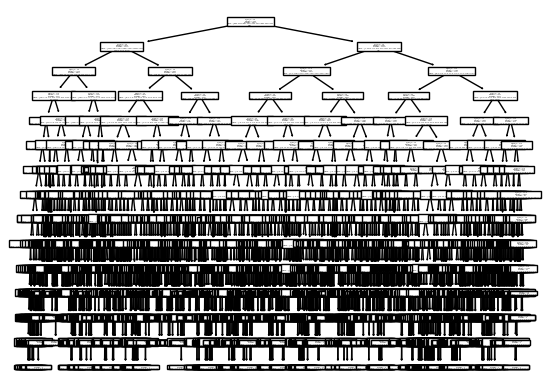

In [16]:
from sklearn.tree import plot_tree
plot_tree(dt)